In [7]:
import numpy as np
import pandas as pd
import random
import time
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# --- 1. DATA GENERATION ---
print("--- Generating Data ---")
random.seed(42)
np.random.seed(42)

def mutate_sequence(seq, error_rate=0.10):
    if error_rate <= 0: return seq
    seq_list = list(seq)
    new_seq = []
    for base in seq_list:
        if random.random() < error_rate:
            r = random.random()
            if r < 0.5: new_seq.append(random.choice("ACGT")) 
            elif r < 0.75: 
                new_seq.append(base)
                new_seq.append(random.choice("ACGT"))
            else: pass 
        else:
            new_seq.append(base)
    return "".join(new_seq)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

# Using a smaller set to verify the fix quickly
n_items = 2000 
pool_bc = [gen_dna(6) for _ in range(n_items)]
pool_ins = [gen_dna(150) for _ in range(n_items)]

data = []
for i in range(n_items):
    n_reads = random.randint(3, 30) # Ensure most clusters have peers
    for _ in range(n_reads):
        data.append({
            "ID": i,
            "Barcode": mutate_sequence(pool_bc[i], 0.02), 
            "Insert": mutate_sequence(pool_ins[i], 0.02)
        })

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} reads (Target Clusters: {n_items})")



# Pick a random barcode


# > from rapidfuzz import process, fuzz
# > choices = ["Atlanta Falcons", "New York Jets", "New York Giants", "Dallas Cowboys"]
# > process.extract("new york jets", choices, scorer=fuzz.WRatio, limit=2)




--- Generating Data ---
Dataset: 33985 reads (Target Clusters: 2000)


In [204]:
from rapidfuzz import process, fuzz
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
import random

seed = 42
random.seed(seed)
np.random.seed(seed)

# --- 1. OPTIMIZED HELPER FUNCTIONS ---

def find_optimal_k_silhouette(Z, distance_matrix, max_k=20):
    """
    Finds the optimal cluster count k by maximizing the Silhouette Score.
    This validates if the clusters are actually tight and separated.
    """
    scores = []
    n_samples = distance_matrix.shape[0]
    
    # Silhouette is undefined for k=1, and impossible if k >= n_samples
    limit_k = min(max_k, n_samples - 1)
    if limit_k < 2:
        return 1 # Fallback if data is too small
        
    possible_ks = range(2, limit_k + 1)
    
    # print(f"   Testing k=2 to {limit_k}...", end="", flush=True)
    
    for k in possible_ks:
        # Cut the tree to get exactly k clusters
        labels = fcluster(Z, t=k, criterion='maxclust')
        
        # Calculate score
        # metric='precomputed' is CRITICAL because we pass a distance matrix
        score = silhouette_score(distance_matrix, labels, metric='precomputed')
        scores.append(score)
        
    print(" Done.")
    
    if not scores: return 1
    
    # Find the winner
    best_idx = np.argmax(scores)
    best_k = possible_ks[best_idx]
    best_score = scores[best_idx]
    
    # print(f"   ✅ Best k: {best_k} (Score: {best_score:.3f})")
    return best_k

# --- 2. MAIN EXECUTION ---

# Assuming 'df' is your existing DataFrame
barcode_counts = df['Barcode'].value_counts()
all_barcodes = np.array(barcode_counts.index.tolist())

n_decoys = 5
if len(all_barcodes) > 0:
    decoy_bcs = random.choices(all_barcodes, k=n_decoys)
else:
    decoy_bcs = []

# Loop through the most common barcode (runs only once due to break)
i = -1
for barcode, count in barcode_counts.items():
    i += 1
    # print(f"Processing Top Barcode: {barcode} | Count: {count}")

    # 1. Fast Filtering
    scores = process.cdist([barcode], all_barcodes, scorer=fuzz.ratio, dtype=np.uint8)[0]
    indices_in_range = np.where(scores > 90)[0]
    filtered_bcs_no_decoys = all_barcodes[indices_in_range]
    filtered_bcs = np.concatenate((all_barcodes[indices_in_range], decoy_bcs))

    # 2. Filter DataFrame
    filtered_df = df[df['Barcode'].isin(filtered_bcs)].copy()
    
    if filtered_df.empty:
        # print("No matches found in DataFrame.")
        break

    print(f"Filtering complete. clustering {len(filtered_df)} reads...")

    # 3. Calculate Distances
    # Barcode Distance (0-100)
    bc_dists_matrix = 100 - process.cdist(
        filtered_df['Barcode'], 
        filtered_df['Barcode'], 
        scorer=fuzz.ratio, 
        dtype=np.float32 # Use float for math safety
    )

    # Insert Distance (0-100)
    ins_dists_matrix = 100 - process.cdist(
        filtered_df['Insert'], 
        filtered_df['Insert'], 
        scorer=fuzz.ratio, 
        dtype=np.float32
    )

    # Combined Distance
    # (Optional: Add scaling here if inserts are decoupled, e.g. ins_dists_matrix * 15)
    combined_distances = bc_dists_matrix + ins_dists_matrix

    # 4. Hierarchical Clustering
    Z_combined = linkage(squareform(combined_distances), method='average')

    # 5. Optimize & Cut (SILHOUETTE METHOD)
    # Pass both the Z matrix and the original distance matrix
    optimal_k = find_optimal_k_silhouette(Z_combined, combined_distances, max_k=30)

    # Apply the cut
    labels_combined = fcluster(Z_combined, t=optimal_k, criterion='maxclust')
    
    # Save results
    filtered_df['Cluster_Combined'] = labels_combined

    filtered_df2 = filtered_df[filtered_df['Barcode'].isin(filtered_bcs_no_decoys)].copy()
    
    print(f"Final Result: Found {len(set(filtered_df2['Cluster_Combined']))} unique clusters, correct would be {len(set(filtered_df2['ID']))}")

    if i > 45:
        break

Filtering complete. clustering 164 reads...
 Done.
Final Result: Found 8 unique clusters, correct would be 8
Filtering complete. clustering 162 reads...
 Done.
Final Result: Found 11 unique clusters, correct would be 11
Filtering complete. clustering 156 reads...
 Done.
Final Result: Found 9 unique clusters, correct would be 9
Filtering complete. clustering 157 reads...
 Done.
Final Result: Found 9 unique clusters, correct would be 10
Filtering complete. clustering 150 reads...
 Done.
Final Result: Found 6 unique clusters, correct would be 6
Filtering complete. clustering 150 reads...
 Done.
Final Result: Found 10 unique clusters, correct would be 10
Filtering complete. clustering 145 reads...
 Done.
Final Result: Found 4 unique clusters, correct would be 4
Filtering complete. clustering 146 reads...
 Done.
Final Result: Found 8 unique clusters, correct would be 8
Filtering complete. clustering 142 reads...
 Done.
Final Result: Found 5 unique clusters, correct would be 5
Filtering comp

In [206]:
filtered_df

# Count unique IDs per Cluster_Combined
counts = filtered_df.groupby('Cluster_Combined')['ID'].nunique()

# Get only clusters with >= 2 unique IDs
valid_clusters = counts[counts >= 2].index

# Filter original df
result_df = filtered_df[filtered_df['Cluster_Combined'].isin(valid_clusters)]
result_df

,ID,Barcode,Insert,Cluster_Combined
586,35,CTCCT,AATGAAGCAATAGATAACACAGTCTATCCTAGAAAAGGTGGCCGTA...,7
1280,72,AAGAAT,AGACTAAGAGCGCTGCGGACATCGACTGTCATTATTTAGGTATCGT...,2
15850,947,AAGAAT,TTGTGATAGACGCTGCGAACCTGATAGATTATCGACTGTAGTTCTG...,2
15851,947,AAGAAT,TTGTGATAGAACGCTGCGAACCTGATACATTATCGACTGTAGTTCT...,2
15852,947,AAGAAT,TTGTGATAGACGCTGCGAACCTGATAGATTATCGACTGTAGTTCTG...,2
15853,947,AAGAAT,TTGTGATAGACGCTGCGAACCAGATAGTATTATCGACTGTAGTTCT...,2
15854,947,AAGAAT,TTGTGATAGACGCTGCGAACCTGATAGATTATCCGACTGTAGTTCT...,2
15855,947,AAGAAT,TTGTGATAGACGCTGCGAACCTGATAGATTATCGACTGTAGTTCTG...,2
15856,947,AAGAAT,TTGTGATAGACGTGCGAACCTGATAGATTATCGACTGTAGTTCTGG...,2
15857,947,AAGAAT,TTGTGATAGACGCTGCGAACCTGATAGATTATCGACTGTAGTTCTG...,2


In [200]:
filtered_df2

,ID,Barcode,Insert,Cluster_Combined
586,35,CTCCT,AATGAAGCAATAGATAACACAGTCTATCCTAGAAAAGGTGGCCGTA...,7
6300,367,CTCCTC,GGAGAGAACCTTGCGCTTAGGAAGTGAGGCCGCTAGAAGCCCTGGT...,10
6301,367,CTCCTC,GAAGAGAACCGTTGCGCTTAGGAAGTGAGGCCGCAGAAGCCCTGGT...,10
6302,367,CTCCTC,GGAGAGAACCGTTGCGCTTAGGAAGTGAGGCCGCAGAAGCCCTGGT...,10
6303,367,CTCCTC,GGAGAGAACCGTTGCGCTTGGAAGTGAGGCCGCTAGAAGCCCTGGT...,10
6304,367,CTCCTC,GGAGAGAACCGTTGCGCTTAGGAAGTGAGGCCGCTAGAAGCCCTGG...,10
6305,367,CTCCTC,GGAGAAACCGTTGCGCTTAGGAAGTGAGGCCGCTAGAAGCCCTGGT...,10
6306,367,CTCCTC,GGAGAGAACCGTTGCGCTTAGGAAGTGAGGCCGCTAGAAGCCCTGG...,10
6307,367,CTCCTC,GGAGAGTACCGTTGCGCTCTAGGAAGTGAGGCCGCTAGAAGCCCTG...,10
6308,367,CTCCTC,GGAGAGAACCGTTCCGCTCTAGAGAGTGAGGCCGCTAGAAGCCCTG...,10


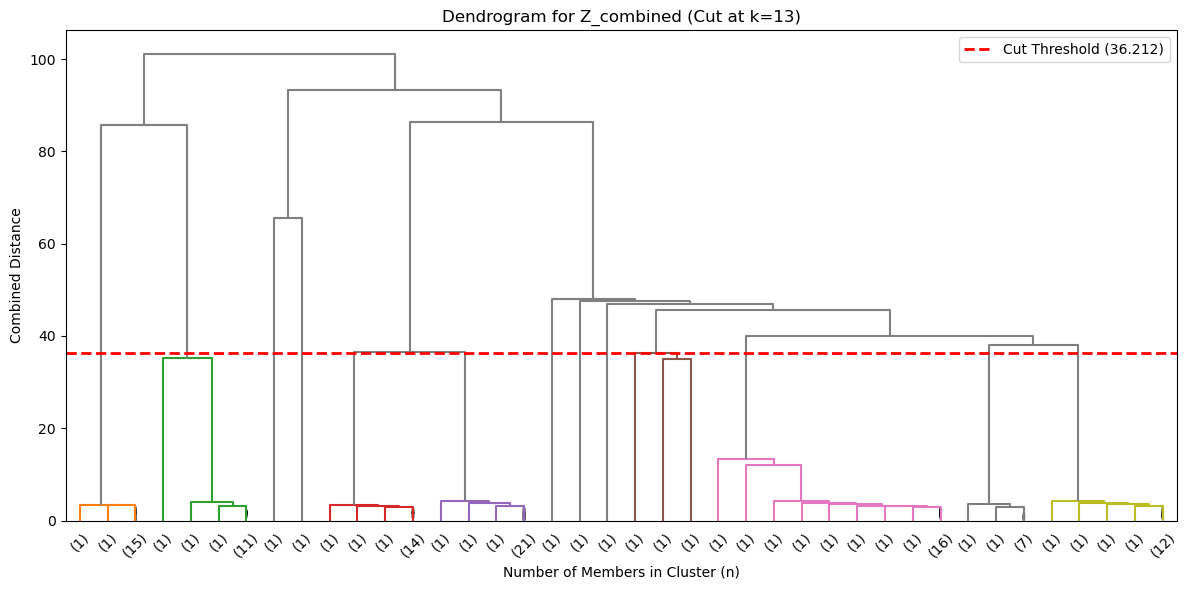

In [203]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import numpy as np

def plot_clean_dendrogram(Z, k=None, p=30):
    """
    Plots a professional dendrogram.
    - Z: Linkage matrix
    - k: The optimal number of clusters (integer). 
         If provided, calculates the threshold automatically.
    - p: Truncate to the top 'p' branches to avoid clutter.
    """
    
    # 1. Calculate the Cut Threshold from K
    # The distance where the merge happened that created 'k' clusters 
    # is found at index [-k] in the Z matrix. 
    # We add a tiny epsilon to ensure the line is drawn just above the split.
    if k:
        threshold = Z[-k, 2] + 0.0001
    else:
        threshold = 0.5 # Default fallback

    plt.figure(figsize=(12, 6))
    plt.title(f"Dendrogram for Z_combined (Cut at k={k})")
    plt.xlabel("Number of Members in Cluster (n)")
    plt.ylabel("Combined Distance")

    # 2. Helper to show Cluster Counts
    n_samples = len(Z) + 1
    def get_cluster_count(id):
        if id < n_samples:
            return "(1)"  # Singleton
        else:
            count = Z[id - n_samples, 3] 
            return f"({int(count)})"

    # 3. Draw Dendrogram
    ddata = dendrogram(
        Z,
        truncate_mode='lastp',
        p=p,
        leaf_rotation=45.,
        leaf_font_size=10.,
        show_contracted=True,
        color_threshold=threshold, # Colors clusters below the cut
        above_threshold_color='grey',
        leaf_label_func=get_cluster_count
    )

    # 4. Draw the Red Cut Line
    plt.axhline(y=threshold, c='r', lw=2, linestyle='--', label=f'Cut Threshold ({threshold:.3f})')
    
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- USAGE ---
# Pass your Z_combined and the optimal_k you calculated
plot_clean_dendrogram(Z_combined, k=optimal_k, p=40)

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

def find_optimal_k_silhouette(Z, distance_matrix, max_k=30):
    """
    Finds the optimal cluster count k by maximizing the Silhouette Score.
    - Z: The linkage matrix
    - distance_matrix: The square distance matrix used to build Zd
    """
    scores = []
    # Silhouette is undefined for k=1, so we start at 2
    # Limit max_k to the number of samples available
    n_samples = distance_matrix.shape[0]
    possible_ks = range(2, min(max_k, n_samples) + 1)
    
    print(f"Testing k=2 to {possible_ks[-1]}...", end="")
    
    for k in possible_ks:
        # Cut the tree to get exactly k clusters
        labels = fcluster(Z, t=k, criterion='maxclust')
        
        # Calculate score
        # metric='precomputed' is CRITICAL because we pass a distance matrix, not raw data
        score = silhouette_score(distance_matrix, labels, metric='precomputed')
        scores.append(score)
        
    print(" Done.")
    
    # Find the winner
    best_idx = np.argmax(scores)
    best_k = possible_ks[best_idx]
    best_score = scores[best_idx]
    
    # --- Plotting ---
    plt.figure(figsize=(10, 5))
    plt.plot(possible_ks, scores, 'o-', color='teal', linewidth=2)
    plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k} (Score={best_score:.3f})')
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score (-1 to +1)")
    plt.title("Silhouette Analysis for Optimal k")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"✅ Auto-Detected Best k: {best_k} (Silhouette Score: {best_score:.3f})")
    
    # Interpretation Check
    if best_score < 0.25:
        print("⚠️ Warning: Score is low (< 0.25). The data might not be structured.")
    elif best_score > 0.5:
        print("🌟 Strong structure detected!")
        
    return best_k

In [133]:
filtered_df

,ID,Barcode,Insert,Cluster_bc,Cluster_insert,Cluster_combined
670,41,ACGCCT,GATTATTCGTTGCGGCCGGTAAATTGAGAATAAAGGCTCTTGAGAT...,7,59,59
671,41,ACGCCT,GATTATTCGTTGCGGCCGGTAAATTGAGAATAAAGGCTCTAGAGAT...,7,55,55
672,41,ACGCCT,GACTATTCGTTGCGGCCGGTAAATTGAGAATAAAGGCTCTTGAGAT...,7,73,73
673,41,ACGCCT,GATTATTCGTTGCGGCCGGTAAATTGAGAATAAAGGCTCTTGAGAT...,7,67,67
674,41,ACGCCT,GATTATTCGTTGGCGGCCGGTAAATTGAGAATAAAGGCTCTTGAGA...,7,51,51
...,...,...,...,...,...,...
32359,1909,ACCGCCT,GGCGAGCCGGCGTTAGACCTTGAACCCGATTAAGGATTAAATTGTC...,8,96,96
32360,1909,ACGCCT,GGCGAGCCGGCGTTAGACCTTGAACCCGATTAAGGATTAAATTGTC...,7,109,109
32361,1909,ACGCCT,GGCGAGCCGGCGTTAGACCTTGAACCCGATTAAGGATTAAATTGTC...,7,102,102
32363,1909,ACGCCT,GGCGAGCCGGCGTTAGACCTTGAACCCGATTAAGGATTAAATTGTC...,7,98,98


In [61]:
from rapidfuzz import process, fuzz
import numpy as np

# Your list of strings
my_strings = ["apple", "ape", "maple", "pineapple"]

# Calculate the pairwise matrix
# scorer=fuzz.ratio uses the standard Levenshtein-based ratio (0-100)
# dtype=np.uint8 is optional but saves memory (since scores are 0-100)
matrix = process.cdist(my_strings, my_strings, scorer=fuzz.ratio, dtype=np.uint8)

print(matrix)

[[100  75  80  71]
 [ 75 100  75  50]
 [ 80  75 100  57]
 [ 71  50  57 100]]


In [49]:
fuzz.ratio('ATGC', 'ATGCATGC')

66.66666666666667

In [107]:
plas1 = "ACGGGATCATCGACTTTGCACACTATGG"

plas2 = mutate_sequence(plas1, 0.1)

print(plas1)
print(plas2)

plas1_bc = "ACGATTT"
plas2_bc = "ACGAAAA"

ACGGGATCATCGACTTTGCACACTATGG
ACGGGATCATCGAGTTTGCGACACTATGG


In [113]:
n1 = 10
n2 = 10

plas1_seqs = [mutate_sequence(plas1) for _ in range(n1)]
plas2_seqs = [mutate_sequence(plas2) for _ in range(n2)]

plas1_bcs = [mutate_sequence(plas1_bc) for _ in range(n1)]
plas2_bcs = [mutate_sequence(plas2_bc) for _ in range(n2)]

plas_seqs = plas1_seqs + plas2_seqs
bc_seqs = plas1_bcs + plas2_bcs

In [140]:
from spoa import poa
_, msa_plasmids = poa(plas_seqs)

bc_gap_penalty = -20

_, msa_bcs = poa(bc_seqs, g=bc_gap_penalty)
msa_bcs

msa = [a + b for a, b in zip(msa_bcs, msa_plasmids)]
msa

['A----C-GATT-------AT-GGG-ATCAT-CGA-CTTT-T-GCAC-CTAGT-GC---',
 'A----T-GATTT------AC-GGG-ATCAT-CGA-CTTT-G-ACA--CTA-T-G-G--',
 'A----C-GATTT------AG-GGG-ATCAT-CGA-CTTT-G-CCACACTA-T-G-G--',
 'A----C-GATTT------AC-GTG-ATCAT-CGA-CTGT-T-GGACACTA-T-G-G--',
 'A----C-GATTT-----AAC-GGT-ATCAT-CGG-C-TT-A-GCACACTA-T-G-G--',
 '-----C-GTTT-------AC-GGG-ATCAT-CG--C--T-T-GCACACTA-T-G-G--',
 'A----C-GATTT------AC-GGA-TTCAT-CGA-CTTT-GCACAC-CTA-T-G-G--',
 '----CC-CATTT------AC-GGGCATCAT-CGA-CTTTCGCACA-ACTA-T-G----',
 'A----C-GATTT------AC-GGG-ATCATCCGA-CTTT-GCACA--CTA-TAG-G--',
 '--G--C-GTATTT-----AC-GGG-ATCAT-CGA-TTGT-GCACA--CTA-T-G-G--',
 'A----C-GA----AAAA-AC--GG-ATCAT-CGAGTTTTCG-ACA--CTA-T-G-GG-',
 'A----C-GA----AAA-ACG-GGT-ACCAT-CGAGTTTGCG-ACAC-C-A-T-G-G--',
 'A----C-GA----AAA--AC-GTG-AT-AT-CGAGTTTCCG-ACA--CTA-T-G-G--',
 'A----C-GG----AAAA-AC-GGG-ATCAT-CGAGTTTACG-ACA--CTA-T-G-G-C',
 '-T---C-GA----AAAA-AC-GGG-ATCAT-CGAGTTTGCG-A-A-ACTA-T-G-G--',
 '---ACC-GA----AAA--AC-GGG-ATCAT-CGAGTTTT-GCGTA--C-A-TA

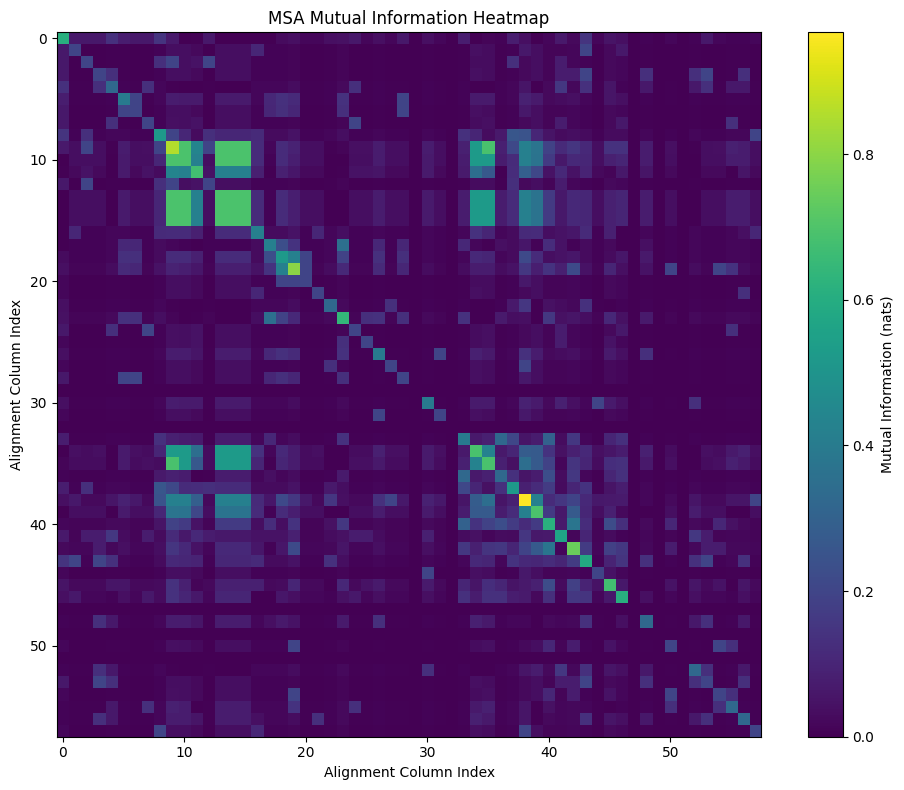

[[0.         0.06334688 0.06334688 ... 0.00979156 0.00979156 0.01839219]
 [0.         0.         0.0026328  ... 0.005412   0.005412   0.0026328 ]
 [0.         0.         0.         ... 0.005412   0.005412   0.0026328 ]
 ...
 [0.         0.         0.         ... 0.         0.01113409 0.005412  ]
 [0.         0.         0.         ... 0.         0.         0.005412  ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [141]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_and_plot_mi(msa_strings, alphabet="ACGTN-"):
    """
    Calculates Mutual Information for an MSA and plots the heatmap.
    """
    # --- 1. Data Preparation ---
    # Convert list of strings to 2D integer array
    msa_array = np.array([list(seq) for seq in msa_strings])
    N, L = msa_array.shape
    vocab_size = len(alphabet)
    
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    msa_int = np.zeros((N, L), dtype=np.int8)
    for char, idx in char_to_int.items():
        msa_int[msa_array == char] = idx

    # --- 2. Probability Calculation (Vectorized) ---
    # One-hot encode: (N, L, A)
    one_hot = np.eye(vocab_size)[msa_int]
    
    # Marginal Probabilities P(x): (L, A)
    P_i = one_hot.mean(axis=0) 
    
    # Joint Probabilities P(x, y): (L, A, L, A)
    # Trick: Use matrix multiplication on flattened vectors to get all pair counts
    # Reshape one_hot to (L*A, N) -> (Variables, Observations)
    flat_view = one_hot.transpose(1, 2, 0).reshape(L * vocab_size, N)
    
    # Compute dot product: (L*A, N) @ (N, L*A) -> (L*A, L*A)
    # This gives the un-normalized joint counts for every char pair at every pos pair
    joint_probs_flat = (flat_view @ flat_view.T) / N
    P_ij = joint_probs_flat.reshape(L, vocab_size, L, vocab_size)
    
    # --- 3. Mutual Information Calculation ---
    # MI = sum_{a,b} P(ia, jb) * log( P(ia, jb) / (P(ia) * P(jb)) )
    
    # Compute product of marginals P(i,a) * P(j,b) for all i,j,a,b
    # Broadcasting: (L, A, 1, 1) * (1, 1, L, A) -> (L, A, L, A)
    P_product = P_i[:, :, None, None] * P_i[None, None, :, :]
    
    # Calculate pointwise MI
    # We use a mask to ignore cases where P_ij is 0 (log(0) is undefined, but limit is 0)
    mask = P_ij > 0
    mi_matrix = np.zeros_like(P_ij)
    mi_matrix[mask] = P_ij[mask] * np.log(P_ij[mask] / P_product[mask])
    
    # Sum over the character dimensions (axis 1 and 3) to get one score per column pair
    mi_scores = mi_matrix.sum(axis=(1, 3))
    
    # --- 4. Plotting ---
    plt.figure(figsize=(10, 8))
    # 'nearest' interpolation keeps pixels sharp, 'origin="upper"' matches matrix indexing
    plt.imshow(mi_scores, cmap='viridis', origin='upper', interpolation='nearest')
    plt.colorbar(label='Mutual Information (nats)')
    plt.title('MSA Mutual Information Heatmap')
    plt.xlabel('Alignment Column Index')
    plt.ylabel('Alignment Column Index')
    
    # Optional: Zero out the diagonal if you only care about contacts
    # np.fill_diagonal(mi_scores, 0)
    
    plt.tight_layout()
    plt.savefig('msa_mi_heatmap.png')
    plt.show()
    
    return mi_scores

import numpy as np

def get_pairwise(mi_scores):
    """
    Calculates the total Mutual Information of all unique pairs, 
    ignoring the diagonal (column self-entropy).
    """
    # np.triu returns the Upper Triangle. k=1 excludes the main diagonal.
    return np.triu(mi_scores, k=1)

# Usage
mi_scores = calculate_and_plot_mi(msa)
pairwise_scores = get_pairwise(mi_scores)
print(pairwise_scores)

ACGGGATCATCGACTTTGCACACTATGG
ACGGGATCATCGAGTTTGCGACACTATGG
A----C-GATT-------AT-GGG-ATCAT-CGA-CTTT-T-GCAC-CTAGT-GC---
A----T-GATTT------AC-GGG-ATCAT-CGA-CTTT-G-ACA--CTA-T-G-G--
A----C-GATTT------AG-GGG-ATCAT-CGA-CTTT-G-CCACACTA-T-G-G--
A----C-GATTT------AC-GTG-ATCAT-CGA-CTGT-T-GGACACTA-T-G-G--
A----C-GATTT-----AAC-GGT-ATCAT-CGG-C-TT-A-GCACACTA-T-G-G--
-----C-GTTT-------AC-GGG-ATCAT-CG--C--T-T-GCACACTA-T-G-G--
A----C-GATTT------AC-GGA-TTCAT-CGA-CTTT-GCACAC-CTA-T-G-G--
----CC-CATTT------AC-GGGCATCAT-CGA-CTTTCGCACA-ACTA-T-G----
A----C-GATTT------AC-GGG-ATCATCCGA-CTTT-GCACA--CTA-TAG-G--
--G--C-GTATTT-----AC-GGG-ATCAT-CGA-TTGT-GCACA--CTA-T-G-G--
A----C-GA----AAAA-AC--GG-ATCAT-CGAGTTTTCG-ACA--CTA-T-G-GG-
A----C-GA----AAA-ACG-GGT-ACCAT-CGAGTTTGCG-ACAC-C-A-T-G-G--
A----C-GA----AAA--AC-GTG-AT-AT-CGAGTTTCCG-ACA--CTA-T-G-G--
A----C-GG----AAAA-AC-GGG-ATCAT-CGAGTTTACG-ACA--CTA-T-G-G-C
-T---C-GA----AAAA-AC-GGG-ATCAT-CGAGTTTGCG-A-A-ACTA-T-G-G--
---ACC-GA----AAA--AC-GGG-ATCAT-CGAGTTTT-GCGTA--C-A-TAC-G

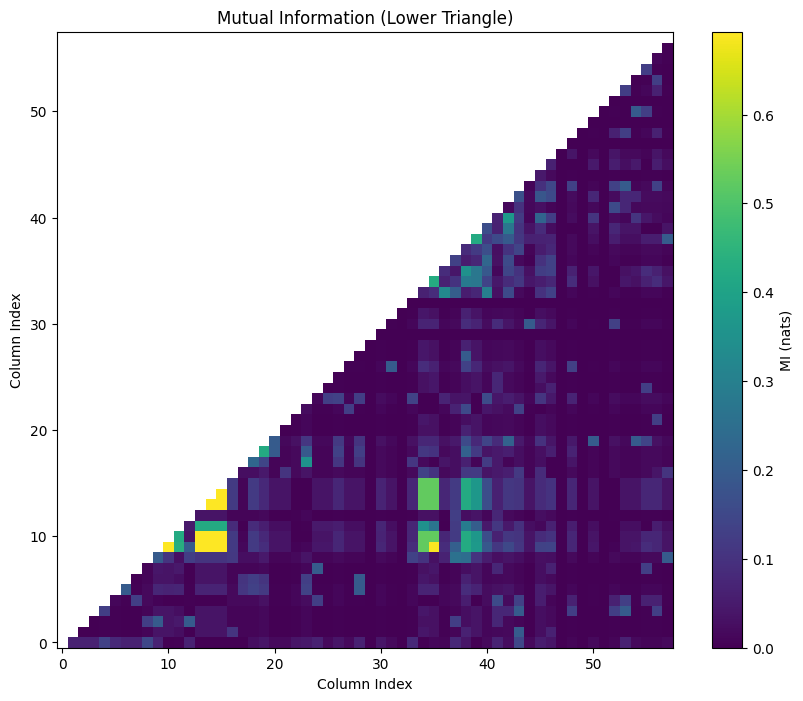

In [142]:
print(plas1)
print(plas2)

for m in msa:
    print(m)

print(mi_scores)

import numpy as np
import matplotlib.pyplot as plt

# Assuming 'mi_scores' is your L x L numpy array

# 1. Create a mask for the matrix lower triangle and diagonal (indices i >= j)
#    We mask these so we are left with i < j, which corresponds to y < x (visual bottom)
mask = np.tril(np.ones_like(mi_scores, dtype=bool), k=0)

# 2. Apply the mask
mi_masked = np.ma.masked_array(mi_scores, mask=mask)

# 3. Plot
plt.figure(figsize=(10, 8))
plt.imshow(mi_masked, origin='lower', cmap='viridis', interpolation='nearest')
plt.xlabel('Column Index')
plt.ylabel('Column Index')
plt.title('Mutual Information (Lower Triangle)')
plt.colorbar(label='MI (nats)')
plt.show()

Real Total MI: 76.6800
Z-Score: 14.19


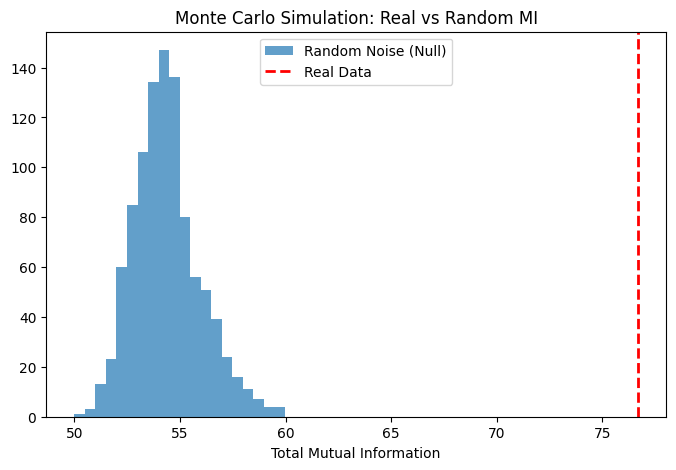

In [144]:
import numpy as np
import matplotlib.pyplot as plt

def encode_msa(msa_strings, alphabet="ACGTN-"):
    """Converts MSA strings to integer matrix and returns vocab info."""
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    msa_array = np.array([list(seq) for seq in msa_strings])
    N, L = msa_array.shape
    
    msa_int = np.zeros((N, L), dtype=np.int8)
    for char, idx in char_to_int.items():
        msa_int[msa_array == char] = idx
        
    return msa_int, len(alphabet)

def get_marginals(msa_int, vocab_size):
    """
    Returns One-Hot encoding (N, L, A) and Marginal Probs P_i (L, A).
    """
    N, L = msa_int.shape
    one_hot = np.eye(vocab_size)[msa_int] # (N, L, A)
    P_i = one_hot.mean(axis=0)            # (L, A)
    return one_hot, P_i

def compute_mi_scores(one_hot, P_i):
    """
    Calculates the MI Matrix using pre-computed One-Hot and Marginals.
    """
    N, L, A = one_hot.shape
    
    # 1. Compute Joint Probs P_ij (Vectorized)
    # Reshape to (Variables, Observations) -> (L*A, N)
    flat_view = one_hot.transpose(1, 2, 0).reshape(L * A, N)
    
    # Dot product -> (L*A, L*A) joint counts, then normalize
    joint_probs_flat = (flat_view @ flat_view.T) / N
    P_ij = joint_probs_flat.reshape(L, A, L, A)
    
    # 2. Compute Expected Probs (Product of Marginals)
    # Broadcasting: (L, A, 1, 1) * (1, 1, L, A)
    P_product = P_i[:, :, None, None] * P_i[None, None, :, :]
    
    # 3. Calculate Pointwise MI
    mask = P_ij > 0
    mi_matrix = np.zeros_like(P_ij)
    mi_matrix[mask] = P_ij[mask] * np.log(P_ij[mask] / P_product[mask])
    
    # Sum over character dimensions to get column-pair scores
    return mi_matrix.sum(axis=(1, 3))

def get_total_mi(mi_scores):
    """Sum of upper triangle (unique pairs, no diagonal)."""
    return np.triu(mi_scores, k=1).sum()

def run_permutation_test(msa_int, vocab_size, n_sims=100):
    """
    Shuffles columns independently to destroy correlation but keep conservation.
    Returns the real score, the Z-score, and the list of random scores.
    """
    N, L = msa_int.shape
    
    # 1. Calculate Real Score (Baseline)
    real_one_hot, P_i = get_marginals(msa_int, vocab_size)
    real_mi_matrix = compute_mi_scores(real_one_hot, P_i)
    real_score = get_total_mi(real_mi_matrix)
    
    print(f"Real Total MI: {real_score:.4f}")
    
    # 2. Simulation Loop
    random_scores = []
    
    # Make a copy to shuffle so we don't destroy original data
    shuffled_int = msa_int.copy()
    
    for i in range(n_sims):
        # Shuffle each column independently
        # (Preserves P_i, so we can reuse the Real P_i!)
        for col in range(L):
            np.random.shuffle(shuffled_int[:, col])
            
        # Re-compute One-Hot and Joint Probs
        # Note: We reuse 'P_i' from above because column conservation didn't change!
        shuffled_one_hot, _ = get_marginals(shuffled_int, vocab_size)
        sim_mi_matrix = compute_mi_scores(shuffled_one_hot, P_i)
        
        random_scores.append(get_total_mi(sim_mi_matrix))
    
    # 3. Stats
    random_scores = np.array(random_scores)
    mean_random = random_scores.mean()
    std_random = random_scores.std()
    
    z_score = (real_score - mean_random) / std_random
    
    return real_score, z_score, random_scores

def plot_results(real_score, random_scores):
    plt.figure(figsize=(8, 5))
    plt.hist(random_scores, bins=20, alpha=0.7, label='Random Noise (Null)')
    plt.axvline(real_score, color='red', linestyle='dashed', linewidth=2, label='Real Data')
    plt.title('Monte Carlo Simulation: Real vs Random MI')
    plt.xlabel('Total Mutual Information')
    plt.legend()
    plt.show()



# ... (Previous helper functions: encode_msa, get_marginals, compute_mi_scores remain the same) ...

def get_outlier_metrics(mi_matrix):
    """
    Extracts key outlier statistics from an MI matrix:
    1. Max Row Sum: The 'hubbiest' position (sum of interactions).
    2. Max Pair: The strongest single link.
    """
    # Create a copy with diagonal zeroed out to avoid self-entropy bias
    # (We use a copy to not affect the original matrix outside this function)
    matrix_no_diag = mi_matrix.copy()
    np.fill_diagonal(matrix_no_diag, 0)
    
    # 1. Row Sums (Total MI per position)
    row_sums = matrix_no_diag.sum(axis=1)
    max_row_sum = row_sums.max()
    
    # 2. Max Single Pair (Strongest contact)
    max_pair = matrix_no_diag.max()
    
    return max_row_sum, max_pair

# 1. Prepare Data
msa_int, vocab_size = encode_msa(msa)

# 2. Run Simulation
# n_sims=100 is usually enough for a quick look; use 1000 for publication
real_score, z_score, random_scores = run_permutation_test(msa_int, vocab_size, n_sims=1000)

# 3. Interpret
print(f"Z-Score: {z_score:.2f}") 
# Z > 3.0 implies strong non-random signal (p < 0.001)

# 4. Plot
plot_results(real_score, random_scores)

Calculating MI for real data...
Real Max Row Sum: 7.8690
Real Max Pair:    0.6931
Running 1000 simulations (shuffling columns)...

Results:
Max Row P-Value:  0.00200
Max Pair P-Value: 0.29870


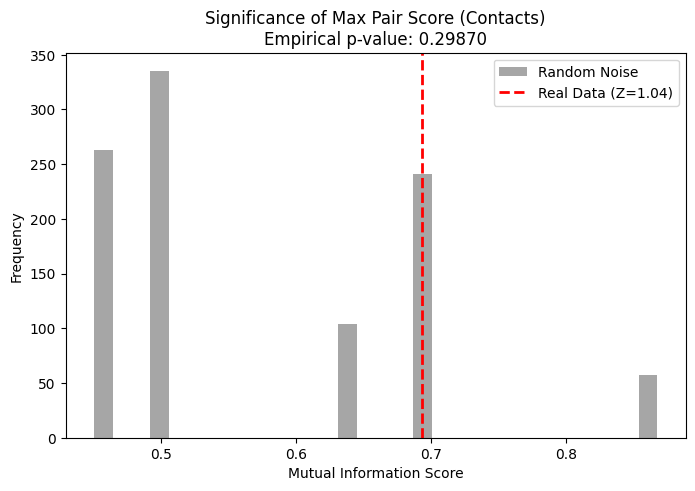

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Helper Functions ---

def encode_msa(msa_strings, alphabet="ACGTN-"):
    """Converts list of MSA strings to an integer matrix."""
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    msa_array = np.array([list(seq) for seq in msa_strings])
    N, L = msa_array.shape
    
    msa_int = np.zeros((N, L), dtype=np.int8)
    for char, idx in char_to_int.items():
        msa_int[msa_array == char] = idx
        
    return msa_int, len(alphabet)

def get_marginals(msa_int, vocab_size):
    """Returns One-Hot encoding (N, L, A) and Marginal Probs P_i (L, A)."""
    # one_hot shape: (N, L, A)
    one_hot = np.eye(vocab_size)[msa_int] 
    # P_i shape: (L, A)
    P_i = one_hot.mean(axis=0)            
    return one_hot, P_i

def compute_mi_scores(one_hot, P_i):
    """Calculates the MI Matrix using pre-computed One-Hot and Marginals."""
    N, L, A = one_hot.shape
    
    # 1. Compute Joint Probs P_ij (Vectorized)
    # Reshape to (Variables, Observations) -> (L*A, N)
    flat_view = one_hot.transpose(1, 2, 0).reshape(L * A, N)
    
    # Dot product -> (L*A, L*A) joint counts, then normalize
    joint_probs_flat = (flat_view @ flat_view.T) / N
    P_ij = joint_probs_flat.reshape(L, A, L, A)
    
    # 2. Compute Expected Probs (Product of Marginals)
    # Broadcasting: (L, A, 1, 1) * (1, 1, L, A) -> (L, A, L, A)
    P_product = P_i[:, :, None, None] * P_i[None, None, :, :]
    
    # 3. Calculate Pointwise MI
    # Use a mask to avoid log(0)
    mask = P_ij > 0
    mi_matrix = np.zeros_like(P_ij)
    mi_matrix[mask] = P_ij[mask] * np.log(P_ij[mask] / P_product[mask])
    
    # Sum over character dimensions (axis 1 and 3) to get column-pair scores
    return mi_matrix.sum(axis=(1, 3))

def get_outlier_metrics(mi_matrix):
    """
    Extracts key outlier statistics from an MI matrix.
    Returns: (Max Row Sum, Max Single Pair Score)
    """
    # Work on a copy with the diagonal removed to avoid self-entropy bias
    matrix_no_diag = mi_matrix.copy()
    np.fill_diagonal(matrix_no_diag, 0)
    
    # 1. Max Row Sum: The "hubbiest" position (sum of all its links)
    max_row_sum = matrix_no_diag.sum(axis=1).max()
    
    # 2. Max Pair: The strongest single structural link
    max_pair = matrix_no_diag.max()
    
    return max_row_sum, max_pair

# --- 2. Main Simulation Function ---

def run_outlier_test(msa_strings, n_sims=1000, alphabet="ACGTN-"):
    """
    Runs Monte Carlo sim to estimate the p-value of the 'outliers'.
    """
    # A. Encode Data
    msa_int, vocab_size = encode_msa(msa_strings, alphabet)
    N, L = msa_int.shape
    
    # B. Calculate Real Data Stats
    print(f"Calculating MI for real data...")
    real_one_hot, P_i = get_marginals(msa_int, vocab_size)
    real_mi_matrix = compute_mi_scores(real_one_hot, P_i)
    real_max_row, real_max_pair = get_outlier_metrics(real_mi_matrix)
    
    print(f"Real Max Row Sum: {real_max_row:.4f}")
    print(f"Real Max Pair:    {real_max_pair:.4f}")

    # C. Simulation Loop
    print(f"Running {n_sims} simulations (shuffling columns)...")
    null_max_rows = []
    null_max_pairs = []
    
    shuffled_int = msa_int.copy()
    
    for i in range(n_sims):
        # Shuffle columns independently
        for col in range(L):
            np.random.shuffle(shuffled_int[:, col])
            
        # Compute MI for shuffled data (Re-use P_i)
        shuffled_one_hot, _ = get_marginals(shuffled_int, vocab_size)
        sim_mi_matrix = compute_mi_scores(shuffled_one_hot, P_i)
        
        # Extract metrics
        sim_max_row, sim_max_pair = get_outlier_metrics(sim_mi_matrix)
        
        null_max_rows.append(sim_max_row)
        null_max_pairs.append(sim_max_pair)

    # D. Calculate P-Values
    # p = (r + 1) / (n + 1)
    null_rows_arr = np.array(null_max_rows)
    null_pairs_arr = np.array(null_max_pairs)
    
    p_val_row = (np.sum(null_rows_arr >= real_max_row) + 1) / (n_sims + 1)
    p_val_pair = (np.sum(null_pairs_arr >= real_max_pair) + 1) / (n_sims + 1)

    print(f"\nResults:")
    print(f"Max Row P-Value:  {p_val_row:.5f}")
    print(f"Max Pair P-Value: {p_val_pair:.5f}")

    # E. Package Results
    results = {
        "max_row": {
            "real": real_max_row,
            "null": null_rows_arr,
            "label": "Max Row Sum (Hubs)",
            "p_value": p_val_row
        },
        "max_pair": {
            "real": real_max_pair,
            "null": null_pairs_arr,
            "label": "Max Pair Score (Contacts)",
            "p_value": p_val_pair
        }
    }
    
    return results

# --- 3. Plotting Function ---

def plot_metric_distribution(result_dict, metric_key="max_pair"):
    """
    Plots the Null Distribution vs Real Value with P-Value.
    """
    data = result_dict[metric_key]
    real_val = data["real"]
    null_dist = data["null"]
    label = data["label"]
    p_val = data["p_value"]
    
    # Calculate Z-Score for visual reference
    mean = null_dist.mean()
    std = null_dist.std()
    z_score = (real_val - mean) / std if std > 0 else 0
    
    plt.figure(figsize=(8, 5))
    plt.hist(null_dist, bins=30, alpha=0.7, color='gray', label='Random Noise')
    plt.axvline(real_val, color='red', linestyle='--', linewidth=2, label=f'Real Data (Z={z_score:.2f})')
    
    plt.title(f'Significance of {label}\nEmpirical p-value: {p_val:.5f}')
    plt.xlabel('Mutual Information Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# --- 4. Execution ---

# Assuming 'msa' is your list of strings
results = run_outlier_test(msa, n_sims=1000)

# Plot 'Contacts' (Single Pair Scores) with p-value
plot_metric_distribution(results, "max_pair")

In [159]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 1. Helper Functions ---

def encode_msa(msa_strings, alphabet="ACGTN-"):
    """Converts list of MSA strings to an integer matrix."""
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    msa_array = np.array([list(seq) for seq in msa_strings])
    N, L = msa_array.shape
    
    msa_int = np.zeros((N, L), dtype=np.int8)
    for char, idx in char_to_int.items():
        msa_int[msa_array == char] = idx
        
    return msa_int, len(alphabet)

def get_marginals(msa_int, vocab_size):
    """Returns One-Hot encoding (N, L, A) and Marginal Probs P_i (L, A)."""
    one_hot = np.eye(vocab_size)[msa_int] 
    P_i = one_hot.mean(axis=0)            
    return one_hot, P_i

def compute_mi_scores(one_hot, P_i):
    """Calculates the MI Matrix using pre-computed One-Hot and Marginals."""
    N, L, A = one_hot.shape
    flat_view = one_hot.transpose(1, 2, 0).reshape(L * A, N)
    joint_probs_flat = (flat_view @ flat_view.T) / N
    P_ij = joint_probs_flat.reshape(L, A, L, A)
    P_product = P_i[:, :, None, None] * P_i[None, None, :, :]
    mask = P_ij > 0
    mi_matrix = np.zeros_like(P_ij)
    mi_matrix[mask] = P_ij[mask] * np.log(P_ij[mask] / P_product[mask])
    return mi_matrix.sum(axis=(1, 3))

def get_all_metrics(mi_matrix):
    """Extracts Total MI, Max Row Sum, and Max Pair Score (ignoring diagonal)."""
    matrix_no_diag = mi_matrix.copy()
    np.fill_diagonal(matrix_no_diag, 0)
    
    # 1. Total MI (Sum of upper triangle)
    total_mi = np.triu(matrix_no_diag, k=1).sum()
    # 2. Max Row Sum
    max_row_sum = matrix_no_diag.sum(axis=1).max()
    # 3. Max Pair
    max_pair = matrix_no_diag.max()
    
    return total_mi, max_row_sum, max_pair

# --- 2. Main Simulation Function (Modified for all 3 metrics) ---

def run_outlier_test(msa_int, vocab_size, n_sims=1000):
    """Runs Monte Carlo sim to estimate p-values for Total, Row, and Pair."""
    N, L = msa_int.shape
    
    # B. Calculate Real Data Stats
    real_one_hot, P_i = get_marginals(msa_int, vocab_size)
    real_mi_matrix = compute_mi_scores(real_one_hot, P_i)
    r_total, r_row, r_pair = get_all_metrics(real_mi_matrix)
    
    # C. Simulation Loop
    n_total, n_row, n_pair = [], [], []
    shuffled_int = msa_int.copy()
    
    for i in range(n_sims):
        for col in range(L):
            np.random.shuffle(shuffled_int[:, col])
        shuffled_one_hot, _ = get_marginals(shuffled_int, vocab_size)
        sim_mi_matrix = compute_mi_scores(shuffled_one_hot, P_i)
        
        s_total, s_row, s_pair = get_all_metrics(sim_mi_matrix)
        n_total.append(s_total)
        n_row.append(s_row)
        n_pair.append(s_pair)

    # D. Calculate P-Values
    p_total = (np.sum(np.array(n_total) >= r_total) + 1) / (n_sims + 1)
    p_row   = (np.sum(np.array(n_row)   >= r_row)   + 1) / (n_sims + 1)
    p_pair  = (np.sum(np.array(n_pair)  >= r_pair)  + 1) / (n_sims + 1)

    return {
        "p_values": (p_total, p_row, p_pair),
        "real_mi_matrix": real_mi_matrix
    }

# --- 3. Splitting Logic (Unchanged) ---

def get_max_pair_indices(mi_matrix):
    """Identifies the indices (col1, col2) of the single highest scoring pair."""
    matrix = mi_matrix.copy()
    np.fill_diagonal(matrix, 0)
    flat_idx = np.argmax(matrix)
    r, c = np.unravel_index(flat_idx, matrix.shape)
    return r, c

def perform_pca_split(msa_int, vocab_size, col_indices):
    """Subsets, PCA, and K-Means split."""
    msa_subset = msa_int[:, col_indices]
    subset_one_hot = np.eye(vocab_size)[msa_subset]
    features = subset_one_hot.reshape(msa_int.shape[0], -1)
    
    pca = PCA(n_components=1)
    pc1_coords = pca.fit_transform(features)
    
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels = kmeans.fit_predict(pc1_coords)
    sil_score = silhouette_score(pc1_coords, labels) if len(labels) > 2 else -1
    
    return labels, sil_score, pc1_coords

# --- 4. Recursive Pipeline (Modified) ---

def recursive_msa_split(msa_strings, p_threshold=0.01, n_sims=1000, alphabet="ACGTN-"):
    """
    Recursively splits MSA until no significant substructure is found.
    Returns a list of MSAs (list of lists of strings).
    """
    # Safety check to prevent crashing on tiny clusters
    if len(msa_strings) < 3:
        return [msa_strings]

    # 1. Encode & Test
    msa_int, vocab_size = encode_msa(msa_strings, alphabet)
    stats = run_outlier_test(msa_int, vocab_size, n_sims=n_sims)
    
    p_total, p_row, p_pair = stats["p_values"]
    print(f"Analyzing {len(msa_strings)} seqs -> P-values: Total={p_total:.4f}, Row={p_row:.4f}, Pair={p_pair:.4f}")
    
    # 2. Decision: If ALL metrics are safe (above threshold), stop.
    if (p_total > p_threshold) and (p_row > p_threshold) and (p_pair > p_threshold):
        print(f"-> No significant signal. Returning cluster.")
        return [msa_strings]
    
    # 3. Split
    print(f"-> SIGNAL DETECTED. Splitting...")
    r, c = get_max_pair_indices(stats["real_mi_matrix"])
    labels, score, _ = perform_pca_split(msa_int, vocab_size, [r, c])
    
    # Create the two new lists
    group_A = [s for i, s in enumerate(msa_strings) if labels[i] == 0]
    group_B = [s for i, s in enumerate(msa_strings) if labels[i] == 1]
    
    # 4. Recurse (Run the exact same function on the children)
    results = []
    results.extend(recursive_msa_split(group_A, p_threshold, n_sims, alphabet))
    results.extend(recursive_msa_split(group_B, p_threshold, n_sims, alphabet))
    
    return results

# --- 5. Usage ---

final_clusters = recursive_msa_split(msa, p_threshold=0.01, n_sims=100)

print(len(final_clusters))
# print(f"Final number of clusters: {len(final_clusters)}")

Analyzing 20 seqs -> P-values: Total=0.0099, Row=0.0099, Pair=0.0099
-> SIGNAL DETECTED. Splitting...
Analyzing 10 seqs -> P-values: Total=0.3465, Row=0.1881, Pair=0.0297
-> No significant signal. Returning cluster.
Analyzing 10 seqs -> P-values: Total=0.1287, Row=0.5545, Pair=0.0198
-> No significant signal. Returning cluster.
2
